#Unveiling the Android App Market: Analyzing Google Play Store Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
apps = pd.read_csv("apps.csv.zip")

apps.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
apps.shape

(9659, 14)

In [5]:
apps.describe()

,Unnamed: 0,Rating,Reviews,Size
count,9659.000000,8196.000000,9.659000e+03,8432.000000
mean,5666.172896,4.173243,2.165926e+05,20.395327
std,3102.362863,0.536625,1.831320e+06,21.827509
min,0.000000,1.000000,0.000000e+00,0.000000
25%,3111.500000,4.000000,2.500000e+01,4.600000
50%,5814.000000,4.300000,9.670000e+02,12.000000
75%,8327.500000,4.500000,2.940100e+04,28.000000
max,10840.000000,5.000000,7.815831e+07,100.000000


In [6]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [7]:
apps.columns

Index(['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size',
       'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='object')

In [10]:
apps.isnull().sum()

,0
Unnamed: 0,0
App,0
Category,0
Rating,1463
Reviews,0
Size,1227
Installs,0
Type,0
Price,0
Content Rating,0


In [11]:
apps.drop_duplicates(inplace=True)

In [12]:
apps.drop("Unnamed: 0", axis=1, inplace=True)

Removed an unnecessary column

In [13]:
apps["Reviews"] = pd.to_numeric(apps["Reviews"], errors="coerce")

In [14]:
apps["Installs"] = apps["Installs"].str.replace(",", "")
apps["Installs"] = apps["Installs"].str.replace("+", "", regex=False)
apps["Installs"] = pd.to_numeric(apps["Installs"])

In [15]:
apps["Price"] = apps["Price"].str.replace("$", "", regex=False)
apps["Price"] = pd.to_numeric(apps["Price"])

In [16]:
apps["Rating"] = pd.to_numeric(apps["Rating"])

In [17]:
apps["Last Updated"] = pd.to_datetime(apps["Last Updated"])

In [19]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9659 non-null   object        
 1   Category        9659 non-null   object        
 2   Rating          8196 non-null   float64       
 3   Reviews         9659 non-null   int64         
 4   Size            8432 non-null   float64       
 5   Installs        9659 non-null   int64         
 6   Type            9659 non-null   object        
 7   Price           9659 non-null   float64       
 8   Content Rating  9659 non-null   object        
 9   Genres          9659 non-null   object        
 10  Last Updated    9659 non-null   datetime64[ns]
 11  Current Ver     9651 non-null   object        
 12  Android Ver     9657 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory usage: 981.1+ KB


#App Categories

In [20]:
apps["Category"].value_counts()

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


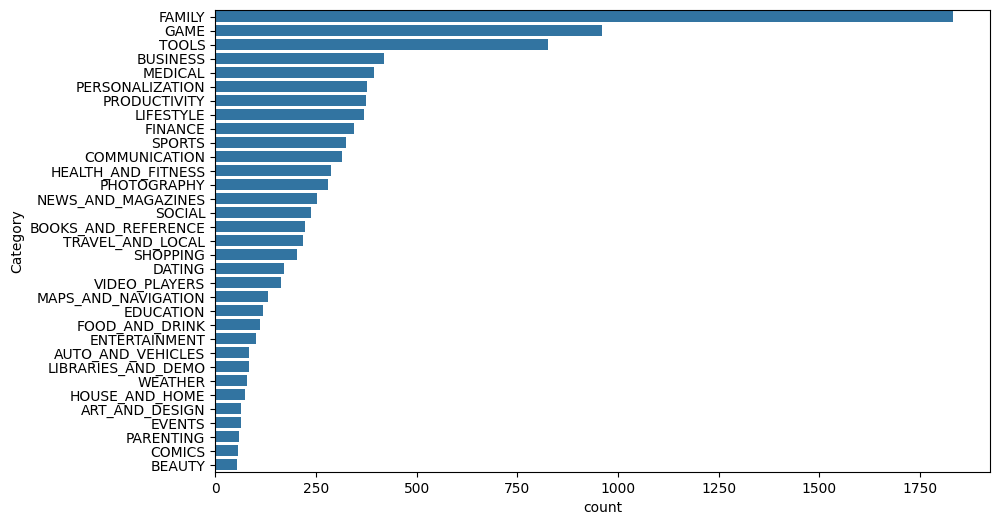

In [21]:
plt.figure(figsize=(10,6))

sns.countplot(y="Category",
              data=apps,
              order=apps["Category"].value_counts().index)

plt.show()

#Rating Distribution

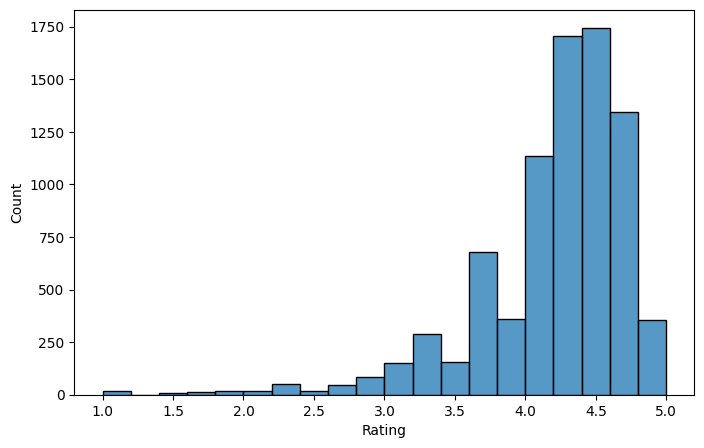

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(apps["Rating"],
             bins=20)

plt.show()

#Top Installed Apps

In [23]:
top = apps.sort_values("Installs",
                       ascending=False)

top[["App","Installs"]].head(10)

,App,Installs
2977,Google News,1000000000
2012,Google+,1000000000
1356,Subway Surfers,1000000000
152,Google Play Books,1000000000
2908,YouTube,1000000000
2003,Instagram,1000000000
2930,Google Play Movies & TV,1000000000
2191,Google Photos,1000000000
2429,Google Street View,1000000000
701,Google Play Games,1000000000


#Free Vs Paid Apps

In [24]:
apps["Type"].value_counts()

,count
Type,
Free,8903
Paid,756


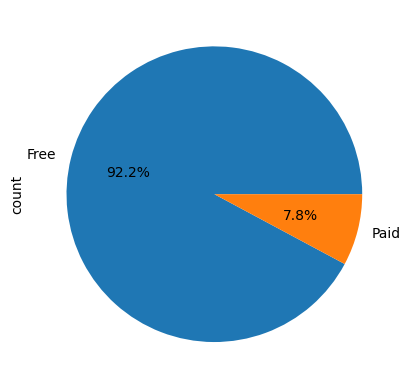

In [25]:
apps["Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.show()

#App Size Analysis

In [27]:
apps["Size"] = apps["Size"].astype(str)
apps["Size"] = apps["Size"].replace("Varies with device", np.nan)

apps["Size"] = apps["Size"].str.replace("M", "")

apps["Size"] = pd.to_numeric(
    apps["Size"],
    errors="coerce"
)

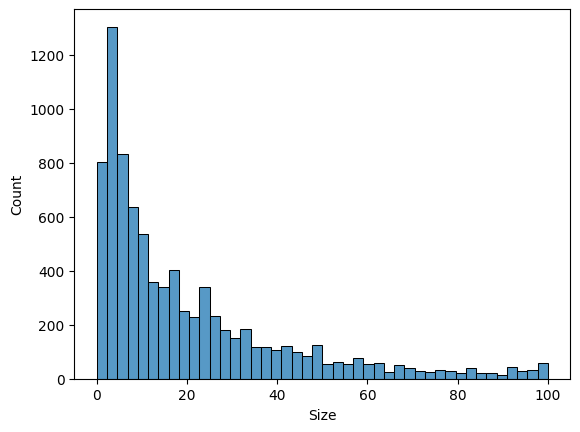

In [28]:
sns.histplot(apps["Size"])

plt.show()

#Sentiment Analysis
lets merge the two datasets and perform more visualizations to get more insights

In [29]:
reviews = pd.read_csv("user_reviews.csv.zip")

reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [30]:
reviews.dropna(inplace=True)

In [31]:
reviews.isnull().sum()

,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


In [32]:
reviews["Sentiment"].value_counts()

,count
Sentiment,
Positive,23998
Negative,8271
Neutral,5158


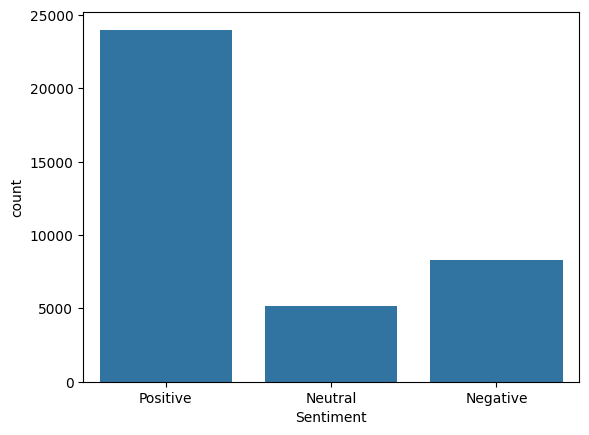

In [33]:
sns.countplot(x="Sentiment",
              data=reviews)

plt.show()

#Merge Both Datasets

In [34]:
merged = pd.merge(
    apps,
    reviews,
    on="App",
    how="left"
)

merged.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,NaN,NaN,NaN,NaN
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000


#Category Vs Sentiment

In [35]:
merged.groupby("Category")[
    "Sentiment_Polarity"
].mean()

,Sentiment_Polarity
Category,
ART_AND_DESIGN,0.234735
AUTO_AND_VEHICLES,0.348683
BEAUTY,0.193360
BOOKS_AND_REFERENCE,0.248422
BUSINESS,0.232189
COMICS,0.449810
COMMUNICATION,0.177275
DATING,0.178846
EDUCATION,0.279332


#Rating vs Sentiment

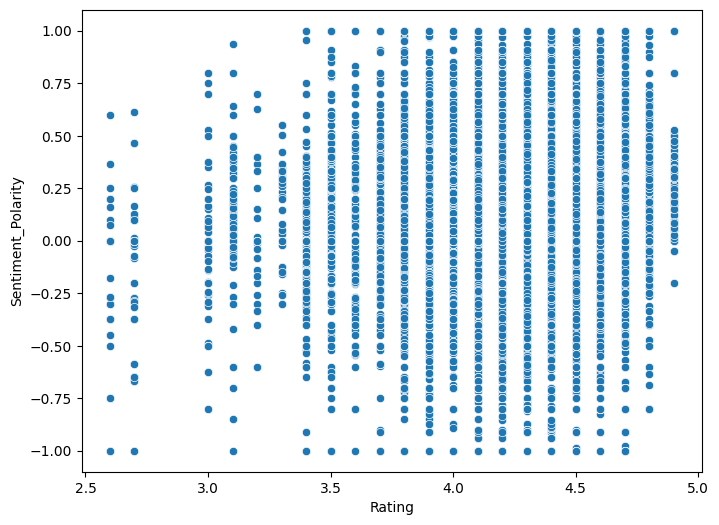

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Rating",
    y="Sentiment_Polarity"
)

plt.show()

###Final Insights

Most Google Play apps are Free.

Family and Game categories contain the highest number of apps.

Higher-rated apps generally receive more positive user sentiments.

Paid apps are fewer compared to free apps.

Applications with higher installs often have a larger number of user reviews.

Positive sentiment is the dominant review category among popular apps.

Some categories have high ratings but lower user sentiment, indicating differences between ratings and written reviews.